In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
data = pd.read_csv("../dataset/titanic.csv")

In [4]:
data.sample(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
643,644,1,3,"Foo, Mr. Choong",male,NaN,0,0,1601,56.4958,NaN,S
203,204,0,3,"Youseff, Mr. Gerious",male,45.5,0,0,2628,7.2250,NaN,C
626,627,0,2,"Kirkland, Rev. Charles Leonard",male,57.0,0,0,219533,12.3500,NaN,Q
290,291,1,1,"Barber, Miss. Ellen ""Nellie""",female,26.0,0,0,19877,78.8500,NaN,S
223,224,0,3,"Nenkoff, Mr. Christo",male,NaN,0,0,349234,7.8958,NaN,S


In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


## doing the analysis for categorical columns

## Counplot

<Axes: xlabel='Survived'>

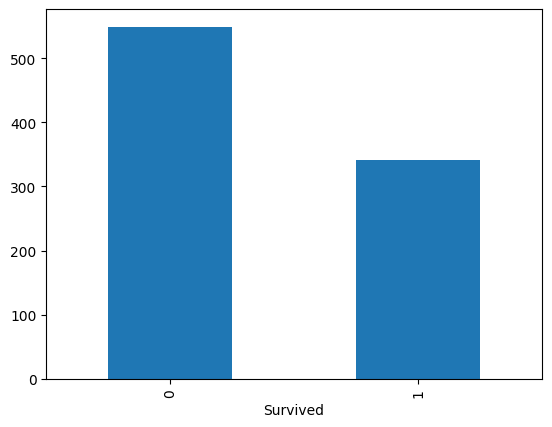

In [11]:
data["Survived"].value_counts().plot(kind="bar")

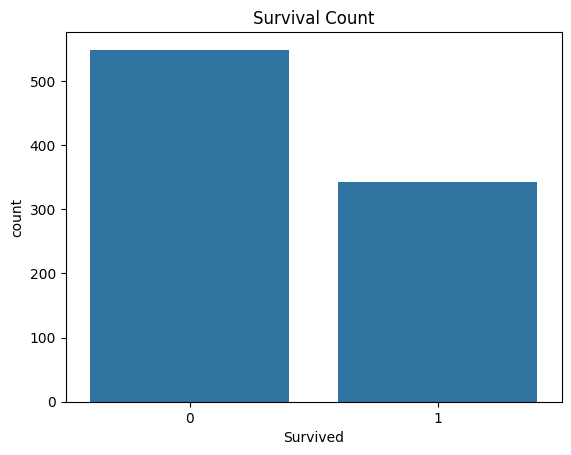

In [ ]:
ax = sns.countplot(x="Survived", data=data)
plt.title("Survival Count")
plt.show()

## Piechart

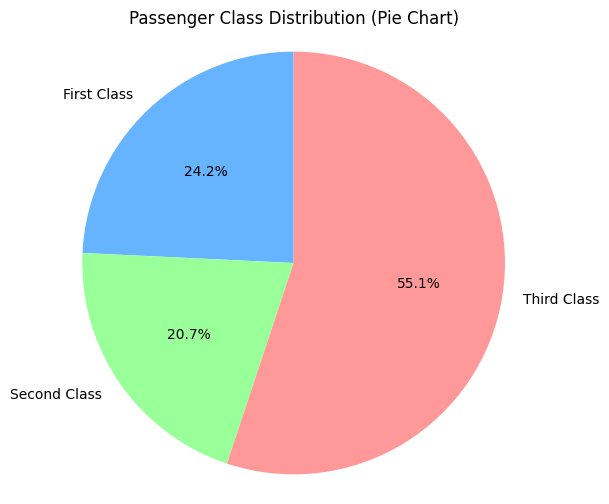

In [26]:
pclass_counts = data["Pclass"].value_counts().sort_index()
plt.figure(figsize=(6, 6))
plt.pie(
    pclass_counts,
    labels=pclass_counts.index.map({1: 'First Class', 2: 'Second Class', 3: 'Third Class'}),
    autopct='%1.1f%%',
    startangle=90,
    colors=['#66b3ff','#99ff99','#ff9999']
)
plt.title("Passenger Class Distribution (Pie Chart)")
plt.axis('equal')
plt.show()

In [27]:
import plotly.express as px

embarked_counts = data["Embarked"].value_counts().sort_index()
embarked_labels = embarked_counts.index.map({'C': 'Cherbourg', 'Q': 'Queenstown', 'S': 'Southampton'})

fig = px.pie(
    names=embarked_labels,
    values=embarked_counts.values,
    title="Embarked Port Distribution (Plotly Pie Chart)",
    color=embarked_labels,
    color_discrete_map={'Cherbourg': '#66b3ff', 'Queenstown': '#99ff99', 'Southampton': '#ff9999'}
)
fig.update_traces(textinfo='percent+label')
fig.show()

## for numerical columns

## histogram check

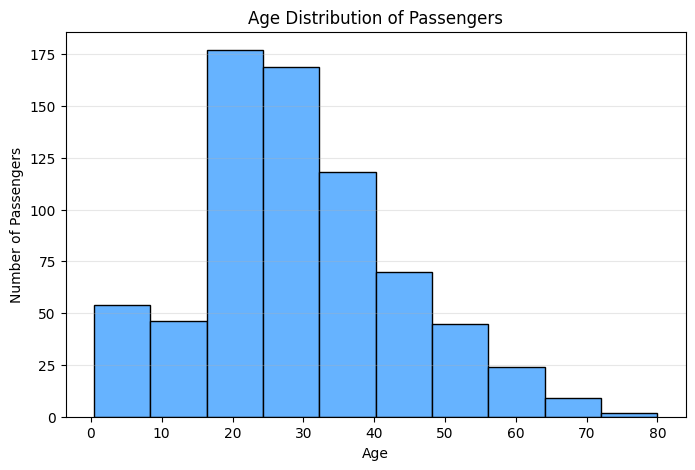

In [29]:
plt.figure(figsize=(8, 5))
plt.hist(data["Age"].dropna(), bins=10, color="#66b3ff", edgecolor="k")
plt.title("Age Distribution of Passengers")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")
plt.grid(axis='y', alpha=0.3)
plt.show()

## as distplot

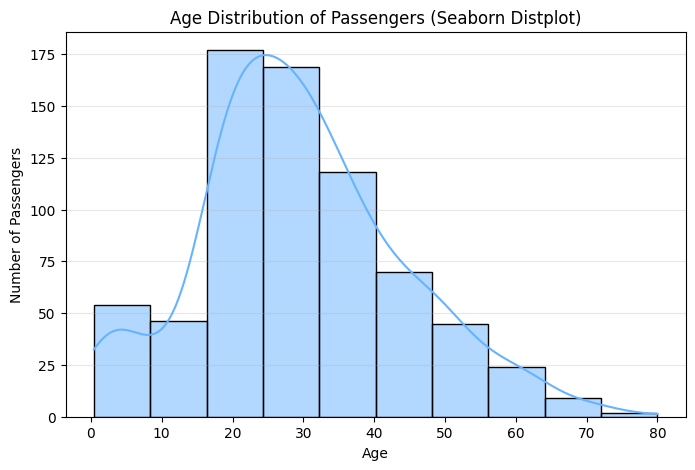

In [30]:
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.histplot(data["Age"].dropna(), kde=True, bins=10, color="#66b3ff", edgecolor="k")
plt.title("Age Distribution of Passengers (Seaborn Distplot)")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")
plt.grid(axis='y', alpha=0.3)
plt.show()

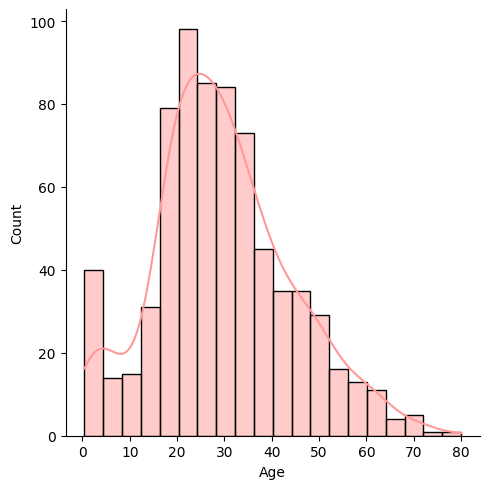

In [38]:
# This code displays the probability density function (PDF) for the Age column by showing a histogram with a KDE (Kernel Density Estimate) overlay
sns.displot(data["Age"].dropna(), kde=True)

## using boxplot

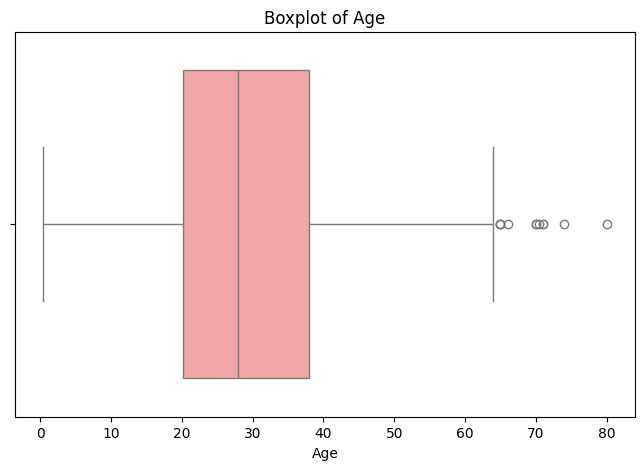

In [41]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=data["Age"])
plt.title("Boxplot of Age")
plt.xlabel("Age")
plt.show()